# Kapitola 9.3: Intervalové odhady

## Definice
Intervalový odhad parametru θ je dvojice (D, H), pro kterou platí:
$ P(D \leq 	\Theta \leq H) = 1 - \alpha $
kde $1 - \alpha$ je **koeficient spolehlivosti** (např. 95 %).

### Typy intervalů:
- **Dvoustranné**: (D, H)
- **Jednostranné**: (-∞, H) nebo (D, ∞)

Šířka intervalu:
$ 	d = |H - D| $

---

## CI (konfidence interval) pro střední hodnotu μ (normální rozdělení)
### 1. Známý rozptyl $\sigma^2$
Dvoustranný intervalový odhad
$$P\left( \bar{x}-  u_{1-\frac{\alpha}{2}} \cdot \frac{\sigma}{\sqrt{n}} < \mu  < \bar{x}+  u_{1-\frac{\alpha}{2}} \cdot \frac{\sigma}{\sqrt{n}}\right)=1-\alpha$$
zkráceně 
$$\displaystyle \bar{x}\pm  u_{1-\frac{\alpha}{2}} \cdot \frac{\sigma}{\sqrt{n}}$$
kde:
- $\bar{x}$ je výběrový průměr
- $z_{1-\alpha/2}$ je kvantil normálního rozdělení


Jednostranné intervalové odhady
$$P\left( \bar{x}-  u_{1-\alpha} \cdot \frac{\sigma}{\sqrt{n}} < \mu  \right)=1-\alpha$$
$$P\left(\mu < \bar{x}+  u_{1-\alpha} \cdot \frac{\sigma}{\sqrt{n}}  \right)=1-\alpha$$

### 2. Neznámý rozptyl (t-rozdělení)
Dvoustranný intervalový odhad
$$P\left( \bar{x}-  t_{1-\frac{\alpha}{2}}(n-1) \cdot \frac{s}{\sqrt{n}} < \mu  < \bar{x}+  t_{1-\frac{\alpha}{2}}(n-1) \cdot \frac{s}{\sqrt{n}}\right)=1-\alpha$$
zkráceně 
$$\displaystyle \bar{x}\pm  t_{1-\frac{\alpha}{2}}(n-1) \cdot \frac{s}{\sqrt{n}}$$
kde:
- $\bar{x}$ je výběrový průměr
- $s$ je výběrová směrodatná odchylka
- $t_{1-\alpha/2}(n-1)$ je kvantil studentovat t-rozdělení se stupni volnosti $n-1$

---

## Vlastnosti CI
- Menší α → širší interval
- Větší n → užší interval
- Větší σ → širší interval


## Interaktivní CI pro střední hodnotu (z vs t)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
from scipy.stats import norm, t

# Funkce pro výpočet šířky intervalu
def confidence_interval(alpha, sigma, n):
    z = norm.ppf(1 - alpha/2)  # kritická hodnota z
    tk = t.ppf(1 - alpha/2, df=n-1)  # kritická hodnota t
    width_z = z * sigma / np.sqrt(n)
    width_t = tk * sigma / np.sqrt(n)
    return width_t, width_z

# Funkce pro vykreslení intervalu
def plot_ci(alpha=0.05, sigma=1.0, n=30):
    mean = 0  # předpokládaná střední hodnota
    width_t, width_z = confidence_interval(alpha, sigma, n)
    lower = mean - width_t
    upper = mean + width_t
    lower_z = mean - width_z
    upper_z = mean + width_z

    plt.figure(figsize=(6, 3))
    plt.axvline(mean, color='blue', linestyle='--', label='Střední hodnota')
    plt.hlines(1, lower, upper, colors='red', linewidth=4, label='Konfidenční interval (t)')
    plt.hlines(0.8, lower_z, upper_z, colors='green', linewidth=4, label='Konfidenční interval (z)')
    plt.xlim(-3, 3)
    plt.ylim(0.5, 1.5)
    plt.title(f"Konfidenční interval (α={alpha:.3f}, σ={sigma:.3f}, n={n})\nŠířka = {2*width_t:.3f} (t), {2*width_z:.3f} (z)")
    plt.legend()
    plt.show()

# Interaktivní ovládací prvky
alpha_slider = FloatSlider(value=0.05, min=0.001, max=0.2, step=0.001, description='alpha')
sigma_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='sigma')
n_slider = IntSlider(value=5, min=2, max=100, step=1, description='n')

# Spuštění interaktivního widgetu
interact(plot_ci, alpha=alpha_slider, sigma=sigma_slider, n=n_slider)


interactive(children=(FloatSlider(value=0.05, description='alpha', max=0.2, min=0.001, step=0.001), FloatSlide…

<function __main__.plot_ci(alpha=0.05, sigma=1.0, n=30)>

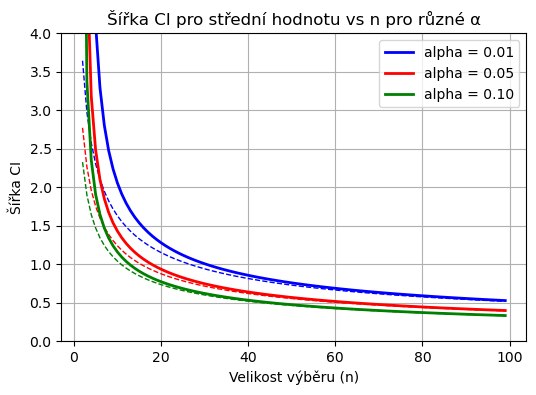

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# Parametry
sigma = 1.0
n_values = np.arange(2, 100)
alpha_values = [0.01, 0.05, 0.10]
colors = ['blue', 'red', 'green']
labels = ['alpha = 0.01', 'alpha = 0.05', 'alpha = 0.10']

plt.figure(figsize=(6, 4))

for alpha, color, label in zip(alpha_values, colors, labels):
    t_val = t.ppf(1 - alpha/2, df=n_values-1)
    z = norm.ppf(1 - alpha/2)
    widths = 2 * t_val * sigma / np.sqrt(n_values)
    widths_z = 2 * z * sigma / np.sqrt(n_values)
    plt.plot(n_values, widths, color=color, linewidth=2, label=label)
    plt.plot(n_values, widths_z, color=color, linestyle='--', linewidth=1)

plt.title("Šířka CI pro střední hodnotu vs n pro různé α")
plt.ylim(0, 4)
plt.xlabel("Velikost výběru (n)")
plt.ylabel("Šířka CI")
plt.legend()
plt.grid(True)
plt.show()


## Simulace pokrytí CI pro střední hodnotu

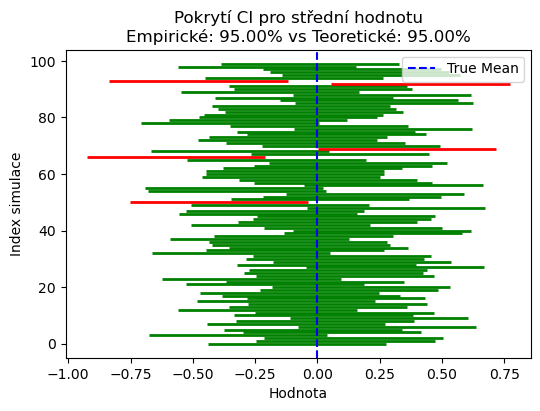

Text(0.5, 0, 'P-hodnota')

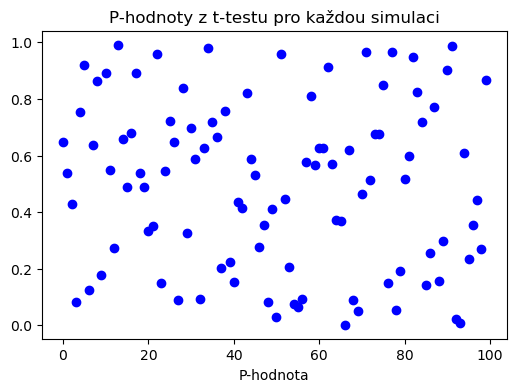

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp

true_mean = 0
sigma = 1
alpha = 0.05
n = 30
num_simulations = 100
z = norm.ppf(1 - alpha/2)
intervals = []
covers = []
p_values = []

for _ in range(num_simulations):
    sample = np.random.normal(true_mean, sigma, n)
    sample_mean = np.mean(sample)
    margin = z * sigma / np.sqrt(n)
    lower = sample_mean - margin
    upper = sample_mean + margin
    intervals.append((lower, upper))
    covers.append(lower <= true_mean <= upper)
    z_stat = (sample_mean - true_mean) / (sigma / np.sqrt(n))
    p_val = 2 * (1 - norm.cdf(abs(z_stat)))
    p_values.append(p_val)

  
    

coverage_rate = np.mean(covers)

plt.figure(figsize=(6, 4))
for i, (lower, upper) in enumerate(intervals):
    color = 'green' if covers[i] else 'red'
    plt.hlines(i, lower, upper, colors=color, linewidth=2)
plt.axvline(true_mean, color='blue', linestyle='--', label='True Mean')
plt.title(f"Pokrytí CI pro střední hodnotu\nEmpirické: {coverage_rate:.2%} vs Teoretické: {(1-alpha):.2%}")
plt.xlabel("Hodnota")
plt.ylabel("Index simulace")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(range(num_simulations), p_values, color='blue')
plt.title("P-hodnoty z t-testu pro každou simulaci")
plt.xlabel("P-hodnota")

Pro parametr $\sigma^2$ normálního rozdělení $\displaystyle \left(\frac{(n-1) s^2}{\chi^2_{1-\frac{\alpha}{2}}(\nu= n-1)};\frac{(n-1) s^2}{\chi^2_{\frac{\alpha}{2}}(\nu= n-1)}\right)$

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
from scipy.stats import chi2

# Funkce pro výpočet intervalu pro sigma
def sigma_confidence_interval(alpha, s, n):
    # Kritické hodnoty chi-kvadrát
    lower_chi = chi2.ppf(alpha/2, df=n-1)
    upper_chi = chi2.ppf(1 - alpha/2, df=n-1)
    # Interval pro rozptyl
    lower_var = (n-1) * (s**2) / upper_chi
    upper_var = (n-1) * (s**2) / lower_chi
    # Interval pro sigma
    lower_sigma = np.sqrt(lower_var)
    upper_sigma = np.sqrt(upper_var)
    return lower_sigma, upper_sigma

# Funkce pro vykreslení intervalu
def plot_sigma_ci(alpha=0.05, s=1.0, n=30):
    lower_sigma, upper_sigma = sigma_confidence_interval(alpha, s, n)
    width = upper_sigma - lower_sigma

    plt.figure(figsize=(8, 4))
    plt.axvline(s, color='blue', linestyle='--', label='Odhad sigma (s)')
    plt.hlines(1, lower_sigma, upper_sigma, colors='red', linewidth=4, label='Konfidenční interval')
    plt.xlim(0, max(upper_sigma*1.2, s*1.5))
    plt.ylim(0.5, 1.5)
    plt.title(f"CI pro sigma (α={alpha:.3f}, s={s:.3f}, n={n})\nInterval: [{lower_sigma:.3f}, {upper_sigma:.3f}], Šířka = {width:.3f}")
    plt.legend()
    plt.show()

# Interaktivní ovládací prvky
alpha_slider = FloatSlider(value=0.05, min=0.001, max=0.2, step=0.001, description='alpha')
s_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='s')
n_slider = IntSlider(value=30, min=2, max=200, step=1, description='n')

# Spuštění interaktivního widgetu
interact(plot_sigma_ci, alpha=alpha_slider, s=s_slider, n=n_slider)


interactive(children=(FloatSlider(value=0.05, description='alpha', max=0.2, min=0.001, step=0.001), FloatSlide…

<function __main__.plot_sigma_ci(alpha=0.05, s=1.0, n=30)>

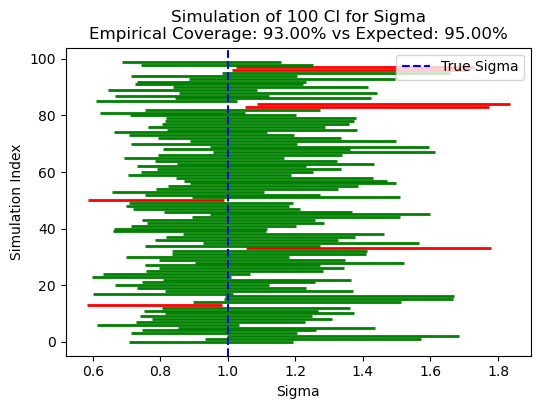

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Simulation parameters
true_sigma = 1.0
alpha = 0.05
n = 30
num_simulations = 100

# Chi-square critical values
lower_chi = chi2.ppf(alpha/2, df=n-1)
upper_chi = chi2.ppf(1 - alpha/2, df=n-1)

intervals = []
covers = []

# Generate samples and compute CI for sigma
for _ in range(num_simulations):
    sample = np.random.normal(0, true_sigma, n)
    sample_var = np.var(sample, ddof=1)
    # CI for variance
    lower_var = (n-1) * sample_var / upper_chi
    upper_var = (n-1) * sample_var / lower_chi
    # Convert to sigma
    lower_sigma = np.sqrt(lower_var)
    upper_sigma = np.sqrt(upper_var)
    intervals.append((lower_sigma, upper_sigma))
    covers.append(lower_sigma <= true_sigma <= upper_sigma)

# Empirical coverage
coverage_rate = np.mean(covers)

# Plot intervals
plt.figure(figsize=(6, 4))
for i, (lower, upper) in enumerate(intervals):
    color = 'green' if covers[i] else 'red'
    plt.hlines(i, lower, upper, colors=color, linewidth=2)
plt.axvline(true_sigma, color='blue', linestyle='--', label='True Sigma')
plt.title(f"Simulation of {num_simulations} CI for Sigma\nEmpirical Coverage: {coverage_rate:.2%} vs Expected: {(1-alpha):.2%}")
plt.xlabel("Sigma")
plt.ylabel("Simulation Index")
plt.legend()
plt.show()
